In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
import shap

# Read in data

In [4]:
model_df = pd.read_csv('model_data.csv')

# Data Preperation

In [9]:
# Define features and target
X = model_df.drop('Churn', axis=1)
y = model_df['Churn']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\n Dataset Shape: {model_df.shape}")
print(f"   Features: {X.shape[1]}")
print(f"   Churn Rate (Full): {y.mean()*100:.2f}%")
print(f"\n Train/Test Split:")
print(f"   Training: {len(X_train)} samples ({y_train.mean()*100:.2f}% churn)")
print(f"   Test: {len(X_test)} samples ({y_test.mean()*100:.2f}% churn)")


 Dataset Shape: (7043, 24)
   Features: 23
   Churn Rate (Full): 26.54%

 Train/Test Split:
   Training: 5634 samples (26.54% churn)
   Test: 1409 samples (26.54% churn)


# Cross Validation set-up

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Baseline Model Training with 5-Fold CV

## Lasso Logistic Regression

In [10]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, class_weight='balanced', max_iter=2000)
lasso_scores = cross_validate(lasso, X_train, y_train, cv=cv, scoring=scoring_metrics)

lasso_results = {
    'Accuracy': lasso_scores['test_accuracy'].mean(),
    'Precision': lasso_scores['test_precision'].mean(),
    'Recall': lasso_scores['test_recall'].mean(),
    'F1': lasso_scores['test_f1'].mean(),
    'ROC-AUC': lasso_scores['test_roc_auc'].mean()
}

print(f"   Accuracy: {lasso_results['Accuracy']:.4f}")
print(f"   Precision: {lasso_results['Precision']:.4f}")
print(f"   Recall: {lasso_results['Recall']:.4f}")
print(f"   F1-Score: {lasso_results['F1']:.4f}")
print(f"   ROC-AUC: {lasso_results['ROC-AUC']:.4f}")

   Accuracy: 0.7488
   Precision: 0.5173
   Recall: 0.8033
   F1-Score: 0.6292
   ROC-AUC: 0.8459


## Random Forest

In [11]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_scores = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring_metrics)

rf_results = {
    'Accuracy': rf_scores['test_accuracy'].mean(),
    'Precision': rf_scores['test_precision'].mean(),
    'Recall': rf_scores['test_recall'].mean(),
    'F1': rf_scores['test_f1'].mean(),
    'ROC-AUC': rf_scores['test_roc_auc'].mean()
}

print(f"   Accuracy: {rf_results['Accuracy']:.4f}")
print(f"   Precision: {rf_results['Precision']:.4f}")
print(f"   Recall: {rf_results['Recall']:.4f}")
print(f"   F1-Score: {rf_results['F1']:.4f}")
print(f"   ROC-AUC: {rf_results['ROC-AUC']:.4f}")

   Accuracy: 0.7879
   Precision: 0.6384
   Recall: 0.4642
   F1-Score: 0.5374
   ROC-AUC: 0.8234


## Gradient Boosting

In [12]:
gb = GradientBoostingClassifier(random_state=42)
gb_scores = cross_validate(gb, X_train, y_train, cv=cv, scoring=scoring_metrics)

gb_results = {
    'Accuracy': gb_scores['test_accuracy'].mean(),
    'Precision': gb_scores['test_precision'].mean(),
    'Recall': gb_scores['test_recall'].mean(),
    'F1': gb_scores['test_f1'].mean(),
    'ROC-AUC': gb_scores['test_roc_auc'].mean()
}

print(f"   Accuracy: {gb_results['Accuracy']:.4f}")
print(f"   Precision: {gb_results['Precision']:.4f}")
print(f"   Recall: {gb_results['Recall']:.4f}")
print(f"   F1-Score: {gb_results['F1']:.4f}")
print(f"   ROC-AUC: {gb_results['ROC-AUC']:.4f}")

   Accuracy: 0.8025
   Precision: 0.6658
   Recall: 0.5164
   F1-Score: 0.5813
   ROC-AUC: 0.8474


## Baseline Model Comparison

In [13]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Lasso Logistic', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lasso_results['Accuracy'], rf_results['Accuracy'], gb_results['Accuracy']],
    'Precision': [lasso_results['Precision'], rf_results['Precision'], gb_results['Precision']],
    'Recall': [lasso_results['Recall'], rf_results['Recall'], gb_results['Recall']],
    'F1-Score': [lasso_results['F1'], rf_results['F1'], gb_results['F1']],
    'ROC-AUC': [lasso_results['ROC-AUC'], rf_results['ROC-AUC'], gb_results['ROC-AUC']]
})

print("\n Model Comparison (5-fold CV on Training Data):")
print(comparison_df.round(4).to_string(index=False))

# Determine best model based on ROC-AUC
best_model_idx = comparison_df.iloc[1:]['ROC-AUC'].idxmax()
best_model_name = comparison_df.iloc[best_model_idx]['Model']
best_model = [lasso, rf, gb][best_model_idx - 1]

print(f"\n Best Model (by ROC-AUC): {best_model_name}")
print(f"   CV ROC-AUC: {comparison_df.iloc[best_model_idx]['ROC-AUC']:.4f}")
print(f"   CV F1-Score: {comparison_df.iloc[best_model_idx]['F1-Score']:.4f}")



 Model Comparison (5-fold CV on Training Data):
            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Lasso Logistic    0.7488     0.5173  0.8033    0.6292   0.8459
    Random Forest    0.7879     0.6384  0.4642    0.5374   0.8234
Gradient Boosting    0.8025     0.6658  0.5164    0.5813   0.8474

 Best Model (by ROC-AUC): Gradient Boosting
   CV ROC-AUC: 0.8474
   CV F1-Score: 0.5813


# Hyperparameter Tuning

## Lasso Logistic Regression

In [16]:
param_grid_lasso = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    }
    
grid_search = GridSearchCV(
    LogisticRegression(penalty='l1', random_state=42, class_weight='balanced'),
    param_grid_lasso,
    cv=cv,
    scoring=scoring_metrics,
    refit='recall',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

# Access results for all metrics
print("Best parameters:", grid_search.best_params_)
print("Best recall score:", grid_search.best_score_)

# Get all metric scores for the best model
results = grid_search.cv_results_
for metric in scoring_metrics.keys():
    mean_scores = results[f'mean_test_{metric}']
    std_scores = results[f'std_test_{metric}']
    best_idx = grid_search.best_index_
    print(f"Best {metric}: {mean_scores[best_idx]:.3f} (+/- {std_scores[best_idx]:.3f})")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

Best parameters: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}
Best recall score: 0.8033444816053512
Best accuracy: 0.749 (+/- 0.014)
Best precision: 0.517 (+/- 0.017)
Best recall: 0.803 (+/- 0.036)
Best f1: 0.629 (+/- 0.021)
Best roc_auc: 0.846 (+/- 0.012)


## Random Forest

In [18]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid search with multiple metrics, refit on RECALL
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring=scoring_metrics,
    refit='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Get best model and results
tuned_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_recall = grid_search.best_score_
print(f"   Best Parameters: {best_params}")
print(f"   Best CV Recall: {best_recall:.4f}")

# Get all metrics for the best model
best_idx = grid_search.best_index_
print("\n   All Metrics for Best Model (CV averages):")
for metric in scoring_metrics.keys():
    mean_score = grid_search.cv_results_[f'mean_test_{metric}'][best_idx]
    std_score = grid_search.cv_results_[f'std_test_{metric}'][best_idx]
    print(f"   {metric.capitalize():10s}: {mean_score:.4f} (+/- {std_score:.4f})")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
   Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV Recall: 0.7278

   All Metrics for Best Model (CV averages):
   Accuracy  : 0.7790 (+/- 0.0141)
   Precision : 0.5650 (+/- 0.0214)
   Recall    : 0.7278 (+/- 0.0338)
   F1        : 0.6360 (+/- 0.0244)
   Roc_auc   : 0.8455 (+/- 0.0111)


## Gradient Boosting

In [21]:
param_grid_gb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 150],
    'max_depth': [3, 5],
    'min_samples_split': [2], 
    'min_samples_leaf': [1],
    'subsample': [0.8, 1.0] 
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring=scoring_metrics,  # ← Changed to dict
    refit='recall',           # ← Added this line
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
best_params = grid_search.best_params_
tuned_cv_recall = grid_search.best_score_  # ← Now RECALL

print(f"   Best Parameters: {best_params}")
print(f"   Best CV Recall: {tuned_cv_recall:.4f}")  # ← Changed to Recall

# Get all metrics
best_idx = grid_search.best_index_
print("\n   All CV Metrics:")
for metric in scoring_metrics:
    score = grid_search.cv_results_[f'mean_test_{metric}'][best_idx]
    print(f"   {metric.capitalize():10s}: {score:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
   Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150, 'subsample': 0.8}
   Best CV Recall: 0.5298

   All CV Metrics:
   Accuracy  : 0.8019
   Precision : 0.6584
   Recall    : 0.5298
   F1        : 0.5868
   Roc_auc   : 0.8464


# Test Data Validation with Lasso Logistic Regression

In [28]:
# Create and train the model
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, class_weight='balanced', max_iter=2000)

# Cross-validation on training data
lasso_scores = cross_validate(lasso, X_train, y_train, cv=cv, scoring=scoring_metrics)

# Print CV results
print("Cross-Validation Results:")
for metric in scoring_metrics.keys():
    mean_score = lasso_scores[f'test_{metric}'].mean()
    std_score = lasso_scores[f'test_{metric}'].std()
    print(f"  {metric.capitalize():10s}: {mean_score:.4f} (+/- {std_score:.4f})")

# Fit the model on the FULL training data
lasso.fit(X_train, y_train)

# predictions using the trained model
y_pred = lasso.predict(X_test)
y_pred_proba = lasso.predict_proba(X_test)[:, 1]

# Calculate test metrics
test_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

print(f"\nFinal Model Performance (TEST SET):")
for metric, value in test_metrics.items():
    print(f"   {metric}: {value:.4f}")

Cross-Validation Results:
  Accuracy  : 0.7488 (+/- 0.0138)
  Precision : 0.5173 (+/- 0.0170)
  Recall    : 0.8033 (+/- 0.0360)
  F1        : 0.6292 (+/- 0.0210)
  Roc_auc   : 0.8459 (+/- 0.0124)

Final Model Performance (TEST SET):
   Accuracy: 0.7388
   Precision: 0.5051
   Recall: 0.7888
   F1-Score: 0.6159
   ROC-AUC: 0.8420


# Lasso Feature Selection Analysis

In [29]:
# Get coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
coef_df['Selected'] = coef_df['Coefficient'] != 0
    
n_selected = coef_df['Selected'].sum()
selected_features = coef_df[coef_df['Selected']]['Feature'].tolist()
    
print(f"   Features selected: {n_selected} out of {len(X.columns)}")
print(f"\n   Top 10 Features by Coefficient Magnitude:")
print(coef_df.head(10).to_string(index=False))
    
# Save feature selection results
coef_df.to_excel('lasso_feature_selection.xlsx', index=False)

   Features selected: 22 out of 23

   Top 10 Features by Coefficient Magnitude:
                       Feature  Coefficient  Selected
             Contract_Two year    -1.426249      True
            InternetService_No    -0.800960      True
   InternetService_Fiber optic     0.763305      True
             Contract_One year    -0.721307      True
                  PhoneService    -0.504607      True
                OnlineSecurity    -0.418217      True
PaymentMethod_Electronic check     0.402120      True
                   TechSupport    -0.353551      True
              PaperlessBilling     0.339458      True
               StreamingMovies     0.237570      True


# SHAP Interpretation

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


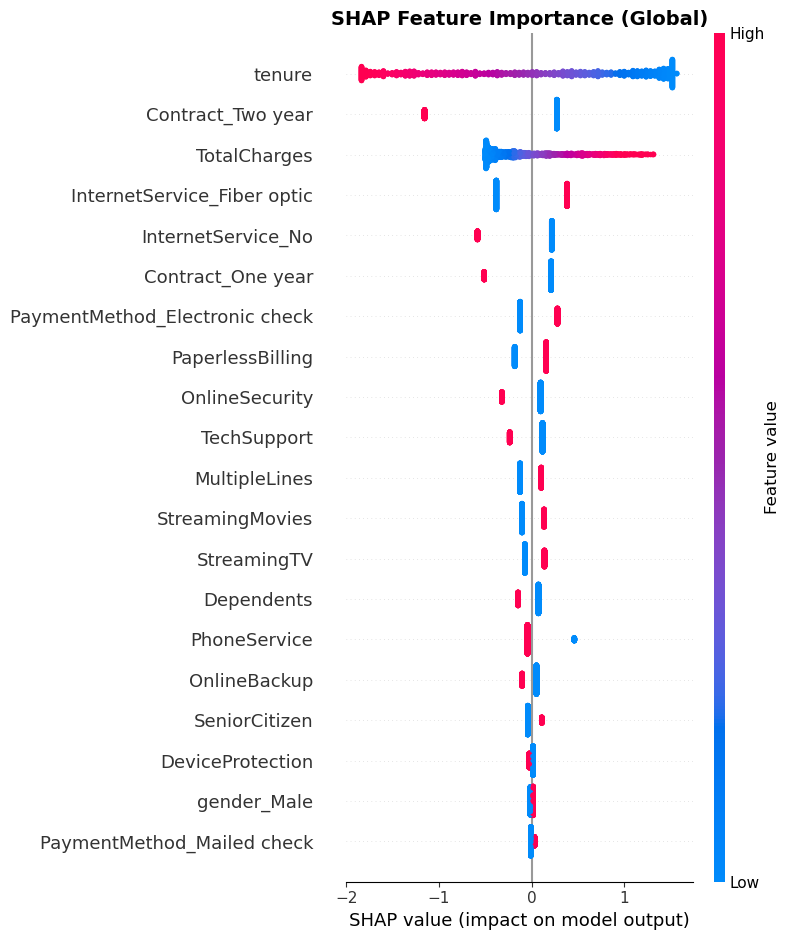

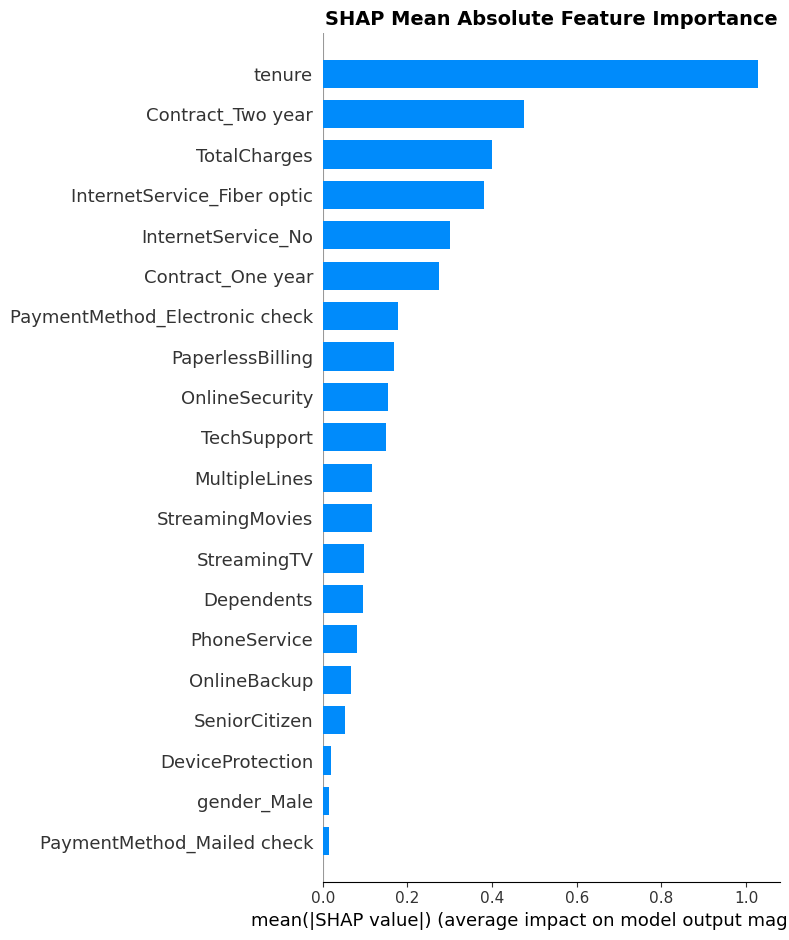


 Top Features by SHAP Importance:
                       Feature  Mean_SHAP
                        tenure   1.028857
             Contract_Two year   0.475255
                  TotalCharges   0.400694
   InternetService_Fiber optic   0.381652
            InternetService_No   0.299527
             Contract_One year   0.273707
PaymentMethod_Electronic check   0.177986
              PaperlessBilling   0.167095
                OnlineSecurity   0.153778
                   TechSupport   0.148767


In [31]:
explainer = shap.LinearExplainer(lasso, X_train, feature_perturbation="interventional")

# Calculate SHAP values on test set (for interpretation)
sample_size = min(1000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Importance)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=450, bbox_inches='tight')
plt.show()

# Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Mean Absolute Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=450, bbox_inches='tight')
plt.show()

# Top Features Comparison
print("\n Top Features by SHAP Importance:")
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0) if len(shap_values.shape) == 2 else np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)
print(shap_importance.head(10).to_string(index=False))

# Confusing Matrix

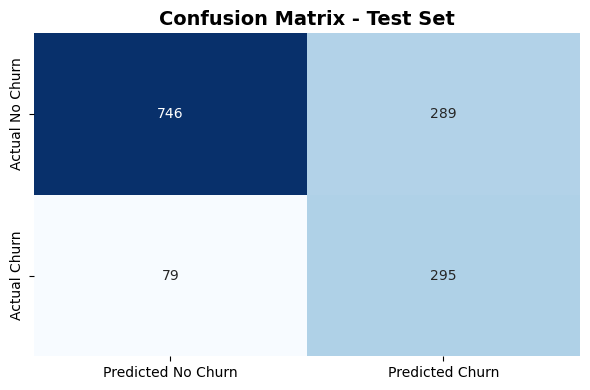

In [33]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, columns=['Predicted No Churn', 'Predicted Churn'],
                     index=['Actual No Churn', 'Actual Churn'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=450, bbox_inches='tight')
plt.show()

# ROC curve

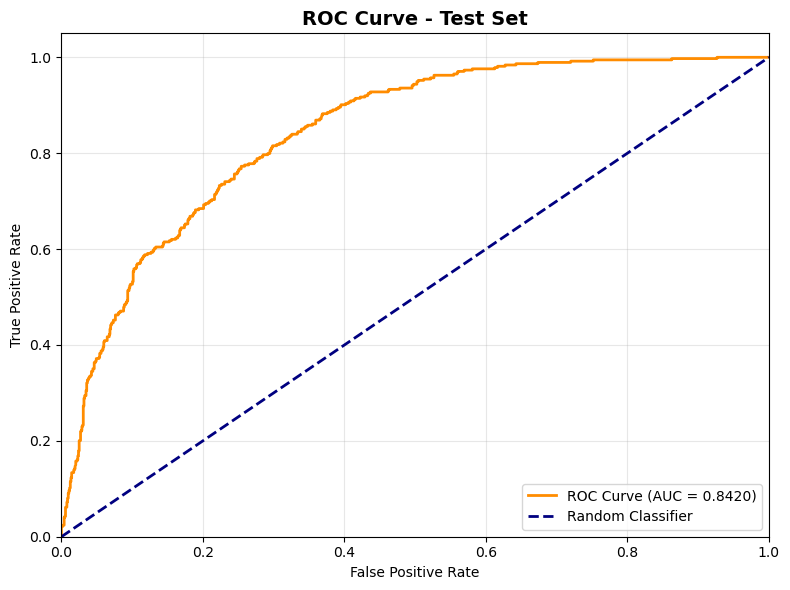

In [34]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=450, bbox_inches='tight')
plt.show()

# Save results

In [35]:
# Create a copy of test features
test_results_df = X_test.copy()

# Add actual target
test_results_df['Actual_Churn'] = y_test.values

# Add predictions
test_results_df['Predicted_Churn'] = y_pred
test_results_df['Predicted_Prob_Churn'] = y_pred_proba

# save as CSV
test_results_df.to_csv('test_predictions.csv', index=False)